# Data Processing

## Objective:
Create a prediction model that will predict a vehicle's MPG, based on other attributes of the vehicle.

## Data Dictionary
mpg - average miles per gallon

cylinders - number of cylinders in the vehicle's engine

displacement - total volume of all cylinders in the engine (cubic centimeters)

horsepower - power the engine produces

weight - weight

acceleration - time in seconds that it takes for the vehicle to reach 60 MPH

model year - year vehicle was released (19XX)

origin - origin country (1 = America, 2 = Europe, 3 = Asia)

car name - car name

## Load csv file and libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(color_codes=True)

C:\Users\codyd\AppData\Local\Temp\ipykernel_20804\2120854967.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Load auto-mpg.csv into dataframe
df = pd.read_csv("auto-mpg.csv")

## Data Overview

In [3]:
# View 10 random rows of the dataframe
df.sample(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
125,20.0,6,198.0,95,3102,16.5,74,1,plymouth duster
368,27.0,4,112.0,88,2640,18.6,82,1,chevrolet cavalier wagon
316,19.1,6,225.0,90,3381,18.7,80,1,dodge aspen
338,27.2,4,135.0,84,2490,15.7,81,1,plymouth reliant
37,18.0,6,232.0,100,3288,15.5,71,1,amc matador
313,28.0,4,151.0,90,2678,16.5,80,1,chevrolet citation
339,26.6,4,151.0,84,2635,16.4,81,1,buick skylark
80,22.0,4,122.0,86,2395,16.0,72,1,ford pinto (sw)
372,27.0,4,151.0,90,2735,18.0,82,1,pontiac phoenix
380,36.0,4,120.0,88,2160,14.5,82,3,nissan stanza xe


In [4]:
# Check number of rows and columns in the dataframe
df.shape

(398, 9)

In [5]:
# Check for duplicate values in the data
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [7]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Thankfully, there does not appear to be any null values in the data.

In [8]:
# Searching for the value "?" in all cells of the dataframe
df[(df.values.ravel() == "?").reshape(df.shape).any(1)].count()

mpg             6
cylinders       6
displacement    6
horsepower      6
weight          6
acceleration    6
model year      6
origin          6
car name        6
dtype: int64

In [9]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [10]:
# Basic statistics for each column
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


### What needs to be cleaned?

Now that we have an overview of the data, next we need to determine what should be cleaned.

<b>Observations:</b>
<ul>
    <li>There are no duplicate rows</li>
    <li>There are very few null values, denoted with a "?"</li>
    <li>There are no obvious outliers, based on the data overview</li>
</ul>

Aside from the view "?" values, there are no obvious tasks that need to be performed, in order for the data to be clean. However, we will still double check, just in case.

## Data Preprocessing

### Missing Values

There were very few null values, denoted with "?", in the data (6 per column). We should first find out which column(s) these values are present in.

In [11]:
# Checks number of rows with null values for each column
# and only displays if there is more than zero

print("Columns with '?' values:")
for column in list(df.columns.values):
    if df.loc[df[column] == '?'].count().any() > 0:
        print(f"- {column}")

Columns with '?' values:
- horsepower


So, horsepower is the only column with missing values. Unfortunately, horsepower is very likely to be a strong indicator of MPG, so these rows will be dropped.

In [12]:
# Initiating new dataframe, without missing value rows
new_df = df[(df['horsepower'] != '?')]

In [13]:
# Double checking to make sure it worked
if new_df.loc[new_df['horsepower'] == '?'].count().any() == 0:
    print("There are no missing values.")

There are no missing values.


### Outliers

There were no values in the data that aren't easily justifiable.

### Check for Inconsistent Data in the Columns

The only column where inconsistent might be present is in the "car name" column. However, while it is possible that there are inconsistent values in the data, it is very difficult to determine <i>which</i> values are inconsistent. This is largely due to the inconsistency of naming conventions in the auto industry; every vehicle often has multiple trim levels, each with their own unique name, and alternative sub-models, also with their own names.

Thankfully, none of this is necessary, because the name of a vehicle has no bearing on its mpg (the make could, but the makes would have to be manually separated from each vehicle's name). Because of this, we will be dropping the column entirely.

In [14]:
df = new_df.drop(['car name'], axis=1)

In [15]:
# Verifying that the 'car name' column was successfully removed
df.sample(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
355,33.7,4,107.0,75,2210,14.4,81,3
348,37.7,4,89.0,62,2050,17.3,81,3
70,13.0,8,400.0,190,4422,12.5,72,1
148,26.0,4,116.0,75,2246,14.0,74,2
72,15.0,8,304.0,150,3892,12.5,72,1
33,19.0,6,232.0,100,2634,13.0,71,1
303,31.8,4,85.0,65,2020,19.2,79,3
281,19.8,6,200.0,85,2990,18.2,79,1
332,29.8,4,89.0,62,1845,15.3,80,2
363,22.4,6,231.0,110,3415,15.8,81,1


## Exploratory Data Analysis

<p style="font-size: 14px; font-weight: 500;">Categorical Features:</p>
<ul>
    <li>Cylinders</li>
    <li>Model Year</li>
    <li>Origin</li>
</ul>

<p style="font-size: 14px; font-weight: 500;">Numerical Features:</p>
<ul>
    <li>Displacement</li>
    <li>Horsepower</li>
    <li>Weight</li>
    <li>Acceleration</li>
</ul>

### Univariate Analysis

#### Exploring Numeric Features: displacement, horsepower, weight, acceleration

<b>Displacement</b>

In [16]:
df.displacement.describe()

count    392.000000
mean     194.411990
std      104.644004
min       68.000000
25%      105.000000
50%      151.000000
75%      275.750000
max      455.000000
Name: displacement, dtype: float64

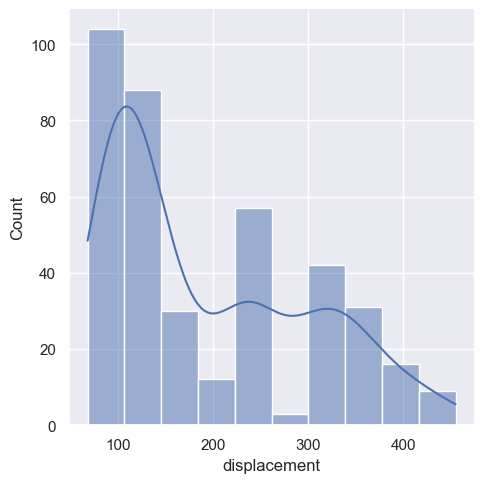

In [17]:
sns.displot(data=df, x='displacement', kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


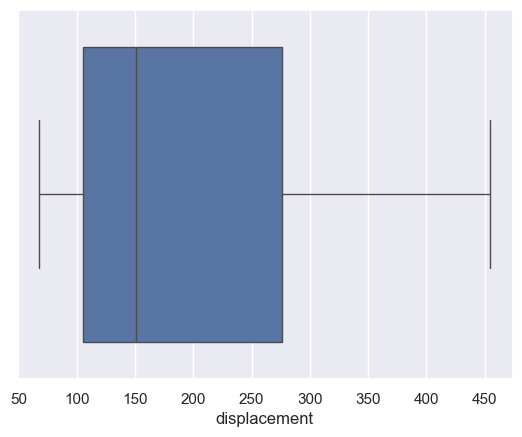

In [18]:
sns.boxplot(data=df, x='displacement');

In [19]:
df['displacement'].mode()

0    97.0
Name: displacement, dtype: float64

<b>Observations:</b>
<ul>
    <li>Displacement: Mean=194.4 Mode=97.0 Median=151.0 Range=68.0-455.0</li>
    <li>Data skewed right</li>
    <li>Very wide range</li>
    <li>Jarring gaps in frequency within middle of data curve (150-200, ~250)</li>
</ul>

<b>Horsepower</b>

Before we can analyze this data, we first need to change the datatype of the column to float.

In [20]:
df['horsepower'] = pd.to_numeric(df['horsepower'])

In [21]:
df.horsepower.describe()

count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64

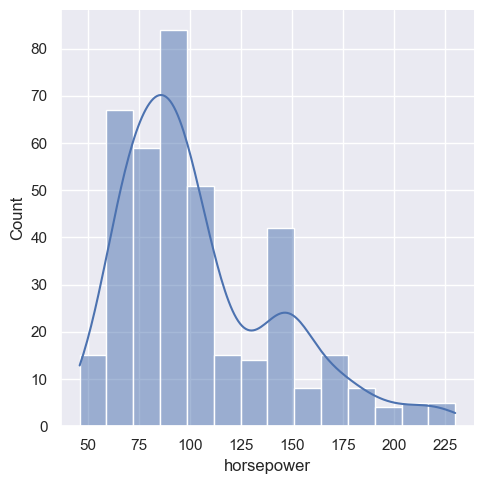

In [22]:
sns.displot(data=df, x='horsepower', kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


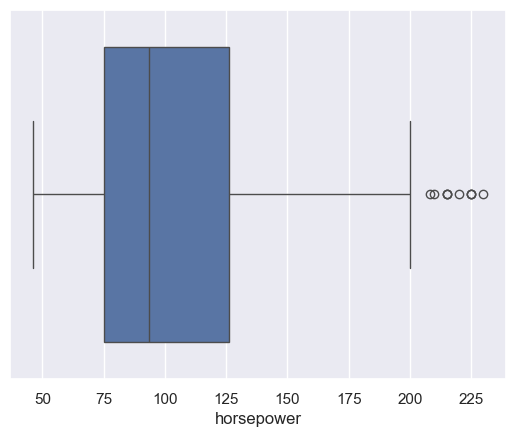

In [23]:
sns.boxplot(data=df, x='horsepower');

In [24]:
df['horsepower'].mode()

0    150
Name: horsepower, dtype: int64

<b>Observations:</b>
<ul>
    <li>Horsepower: Mean=104.47 Mode=150 Median=93.5 Range=46.0-230.0</li>
    <li>Data skewed right</li>
    <li>Few values outside upper fence</li>
    <li>Frequency drops considerably after 100, then spikes again at 150</li>
</ul>

<b>Weight</b>

In [25]:
df.weight.describe()

count     392.000000
mean     2977.584184
std       849.402560
min      1613.000000
25%      2225.250000
50%      2803.500000
75%      3614.750000
max      5140.000000
Name: weight, dtype: float64

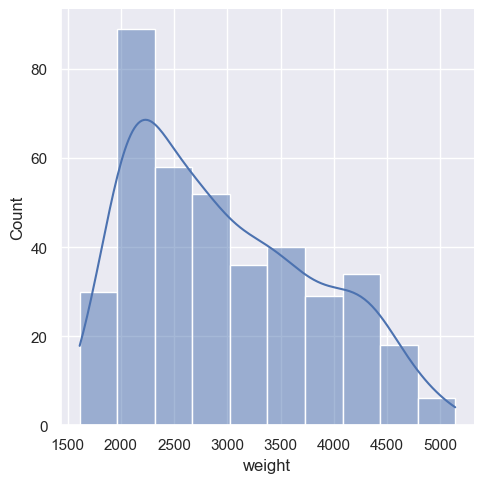

In [26]:
sns.displot(data=df, x='weight', kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


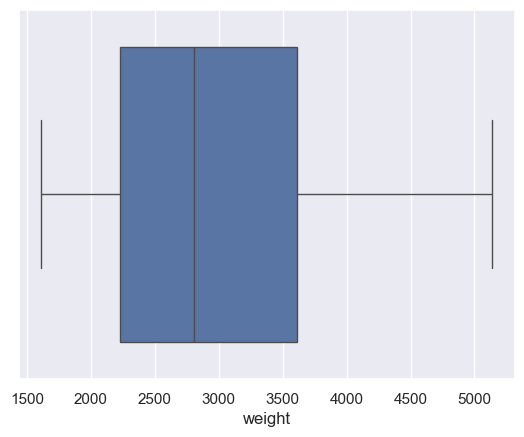

In [27]:
sns.boxplot(data=df, x='weight');

In [28]:
df['weight'].mode()

0    1985
1    2130
Name: weight, dtype: int64

<b>Observations:</b>
<ul>
    <li>Weight: Mean=2977.58 Mode=1985/2130 Median=2803.5 Range=1613.0-5140.0</li>
    <li>Data skewed right</li>
    <li>Data much less intensely skewed than previous columns</li>
</ul>

<b>Acceleration</b>

In [29]:
df.acceleration.describe()

count    392.000000
mean      15.541327
std        2.758864
min        8.000000
25%       13.775000
50%       15.500000
75%       17.025000
max       24.800000
Name: acceleration, dtype: float64

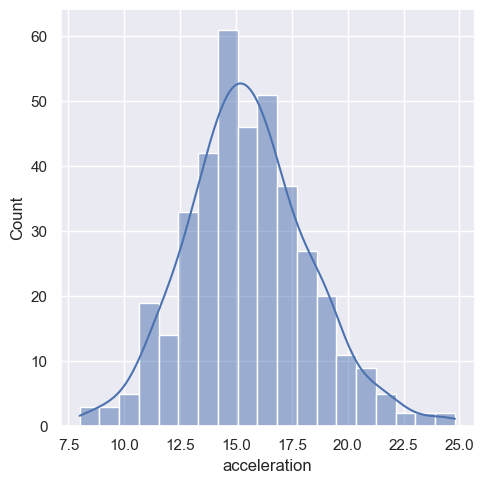

In [30]:
sns.displot(data=df, x='acceleration', kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


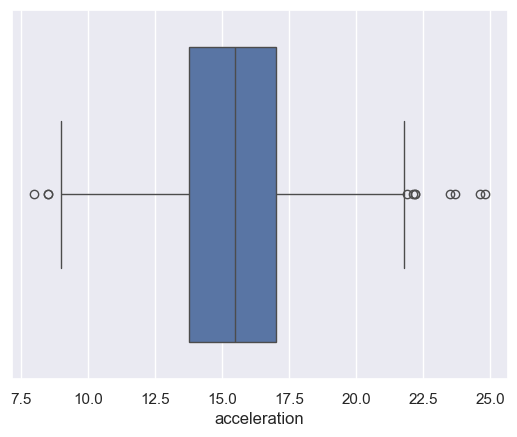

In [31]:
sns.boxplot(data=df, x='acceleration');

In [32]:
df['acceleration'].mode()

0    14.5
Name: acceleration, dtype: float64

<b>Observations</b>
<ul>
    <li>Acceleration: Mean=15.54 Mode=14.5 Median=15.5 Range=8.0-24.8</li>
    <li>Normal distribution</li>
    <li>Few values outside of lower and upper fences</li>
</ul>

#### Exploring Categorical Features: cylinders, model year, origin

<b>Cylinders</b>

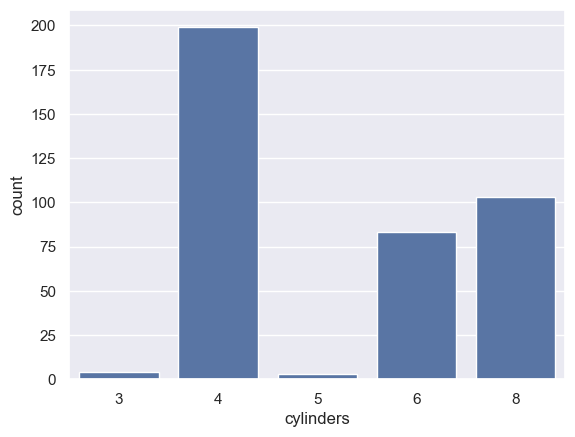

In [33]:
sns.countplot(data=df, x='cylinders');

<b>Observations:</b>
<ul>
    <li>4 cylinders is the most common, following by 8 and 6.</li>
    <li>3 and 5 cylinders exist, but are highly uncommon</li>
</ul>

<b>Model Year</b>

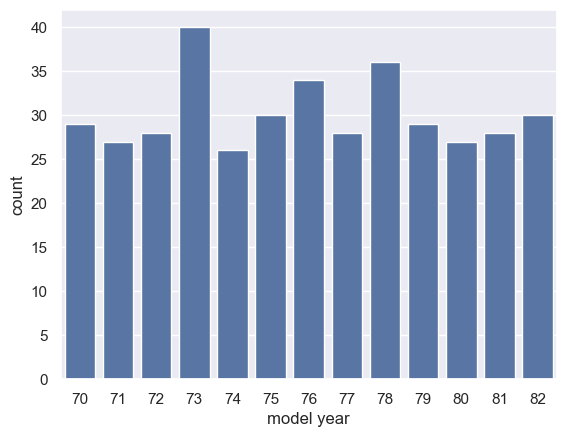

In [34]:
sns.countplot(data=df, x='model year');

<b>Observation:</b> Data frequency rather uniform, aside from 73

<b>Origin</b>

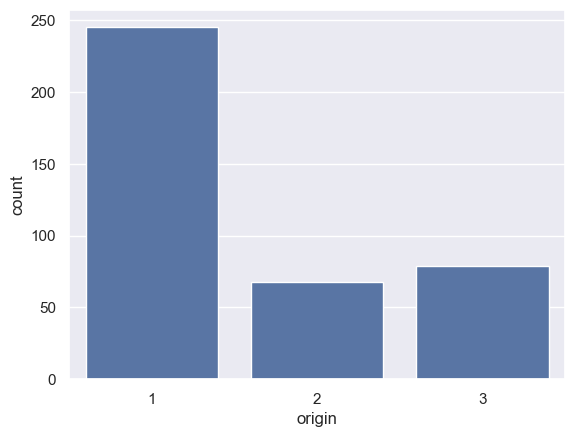

In [35]:
sns.countplot(data=df, x='origin');

<b>Observation:</b> American cars are the most common, by far, followed by Japanese, then European.

### Bivariate Analysis

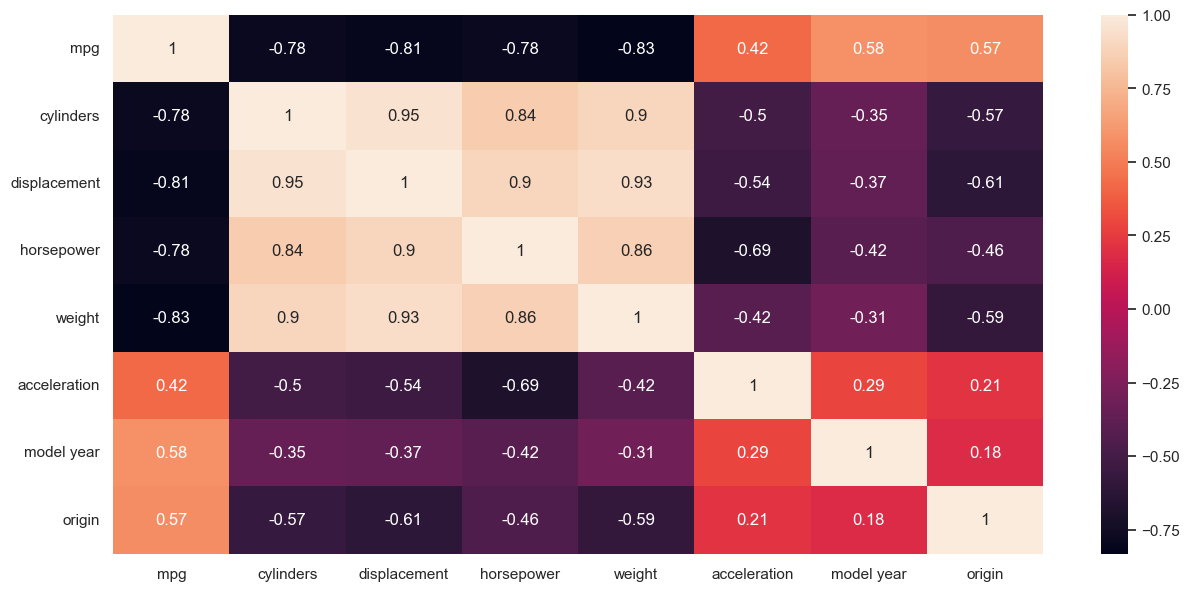

In [36]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True);

Prior to denoting observations, it should be said that deciphering this data is somewhat counter-intuitive, for a couple of reasons, which will be addressed briefly.

<b>Engine Size</b>

Unsurprisingly, cylinder count, displacement, horsepower, and weight all have very strong correlations to one another. This is because displacement is a measure of total cylinder volume in cubic centimeters, meaning more cylinders means more cylinder volume. More displacement means the engine can pull more air and fuel, which leads to higher power production per turn of the crankshaft, and thus higher horsepower (this is referred to as volumetric efficiency). Finally, of course, the engine will weigh more, because it is larger.

So then, it should go without saying, that larger engines get less MPG, as they burn more fuel per turn of the crankshaft. This means that all of: cylinders, displacement, horsepower, and weight, are all roughly equal, in terms of being negatively correlated with MPG.

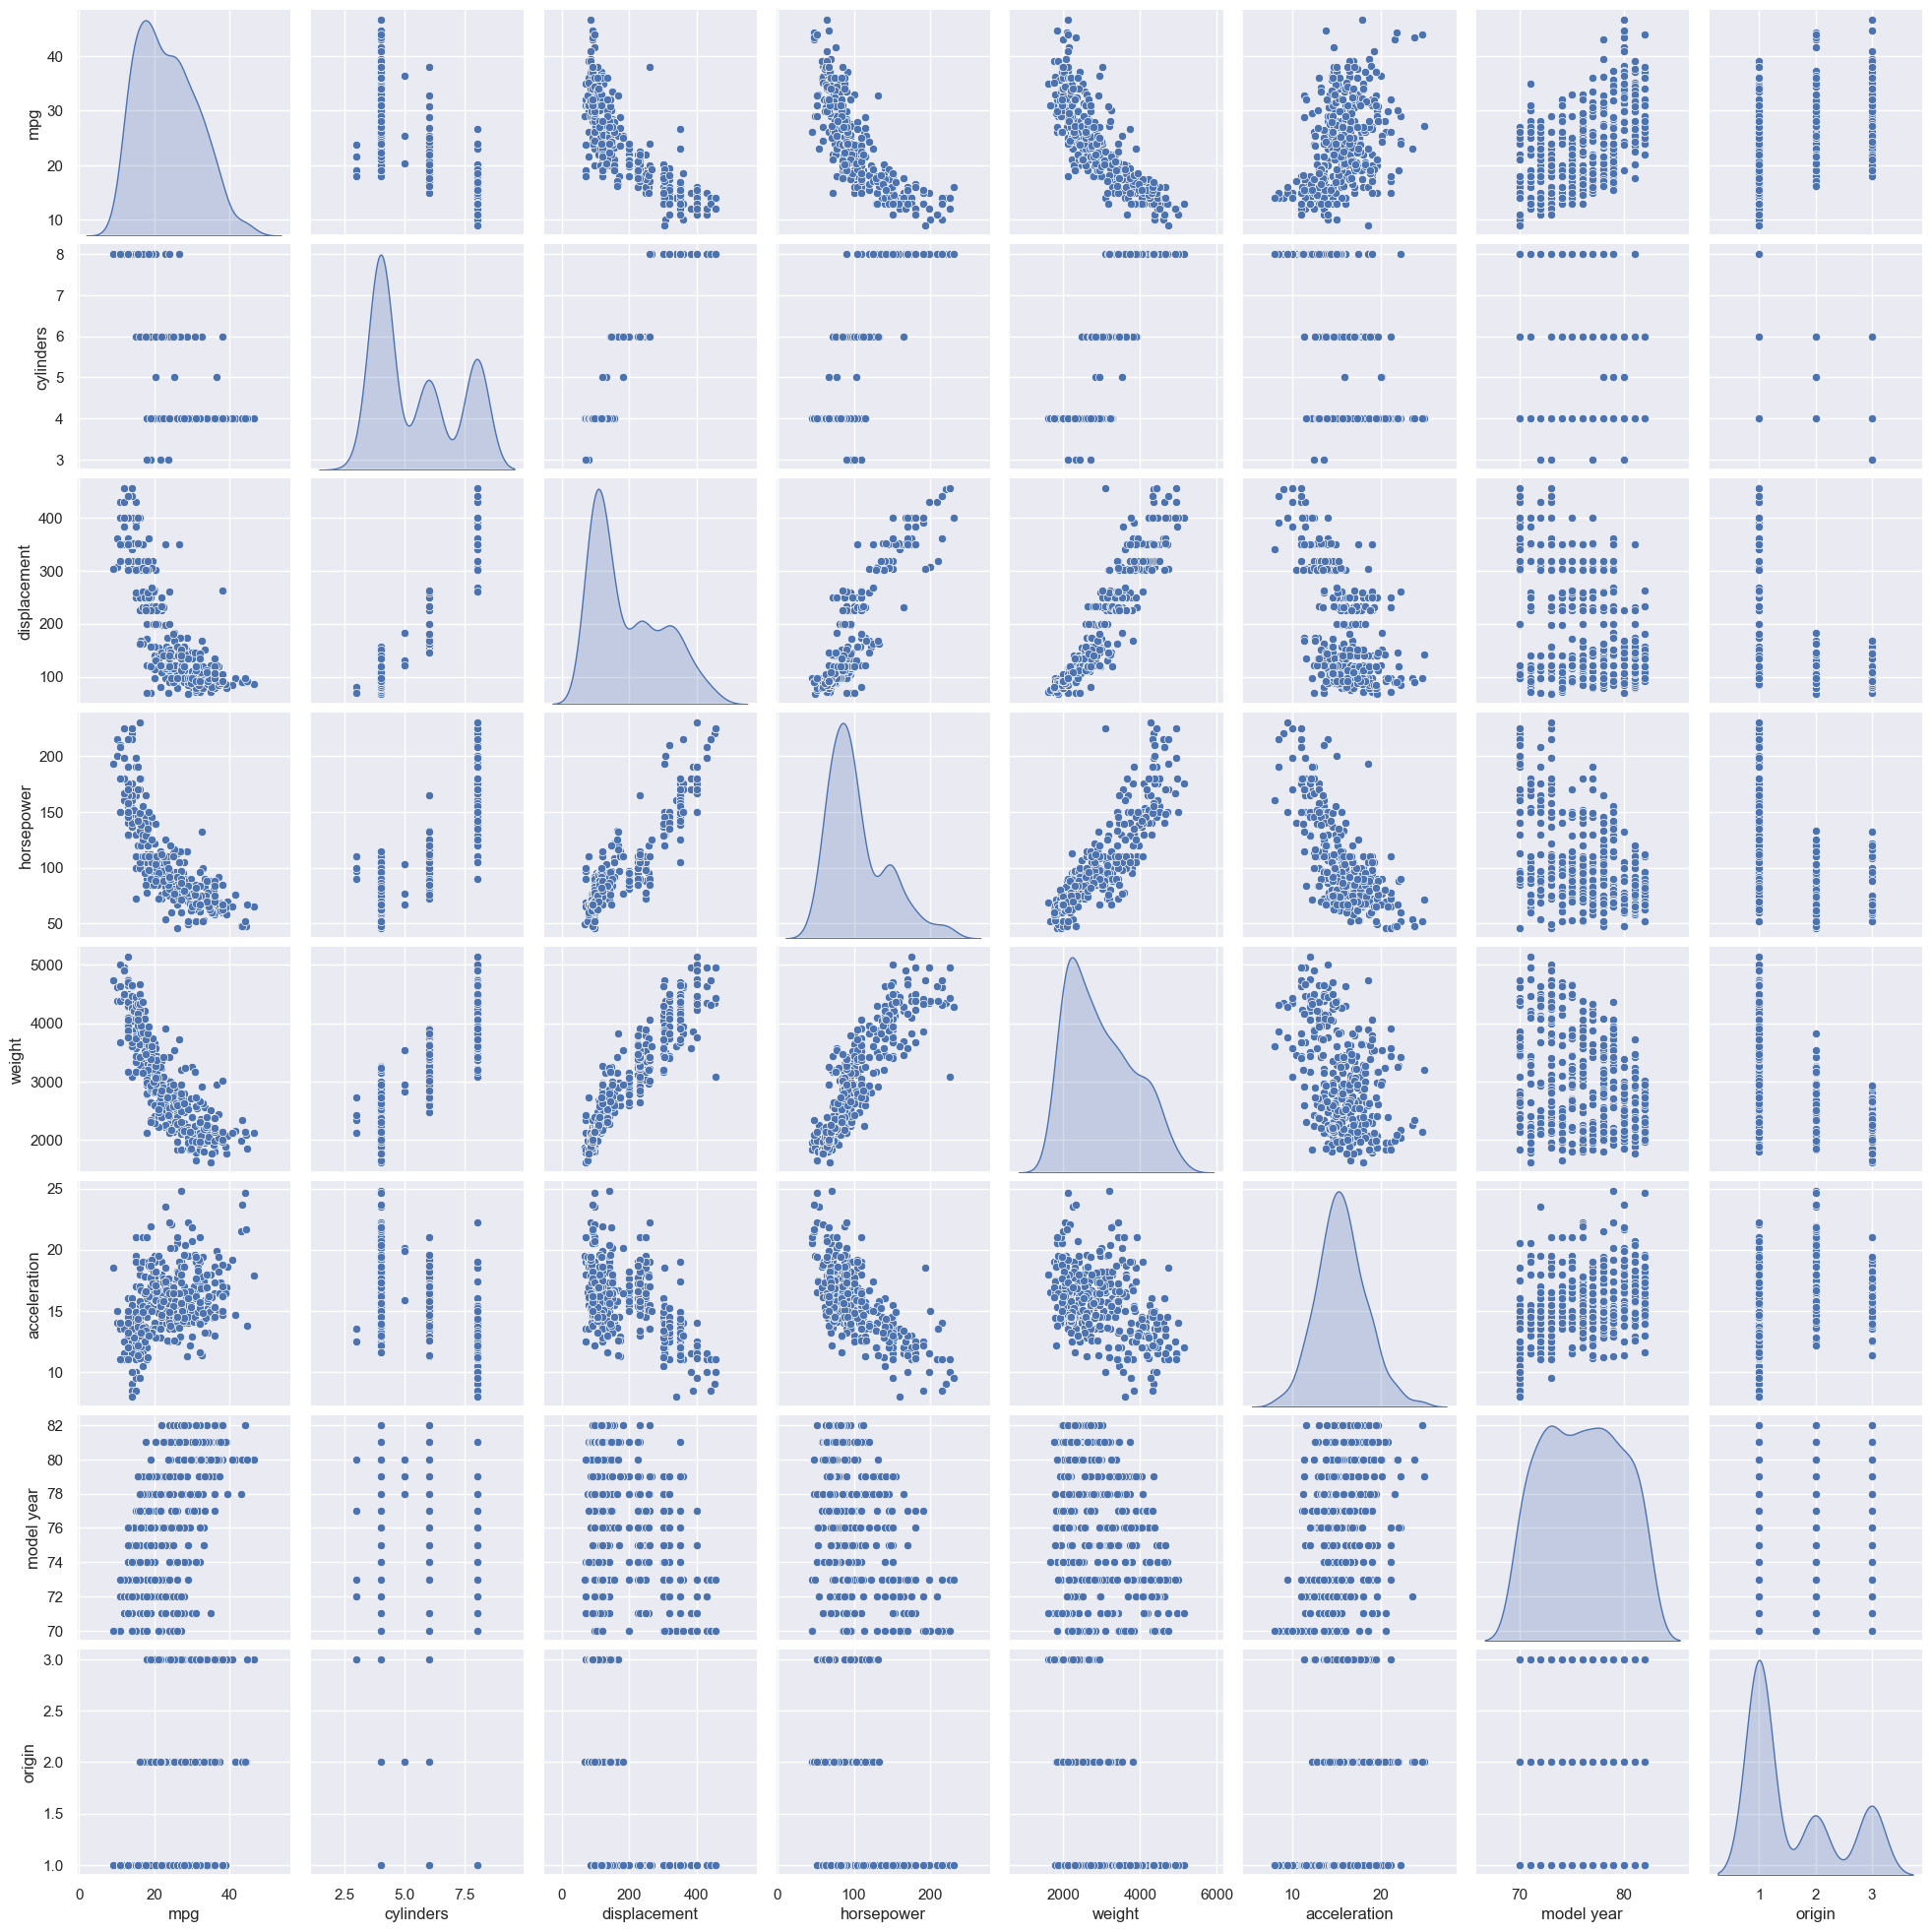

In [37]:
sns.pairplot(df, diag_kind="kde");

#### Mean values of numeric columns, based on mpg

In [38]:
# Separating into dataframes with rows above and below the mean mpg value
average = df['mpg'].mean()
above = df[df['mpg'] >= average]
below = df[df['mpg'] < average]
# Printing mean of each column below and above the mean
print("Below mpg average:")
for column in list(below.columns.values):
    print(f"{column}: {below.loc[:, column].mean()}")

print("\nAbove mpg average:")
for column in list(above.columns.values):
    print(f"{column}: {above.loc[:, column].mean()}")

Below mpg average:
mpg: 17.217961165048543
cylinders: 6.660194174757281
displacement: 267.4611650485437
horsepower: 128.19417475728156
weight: 3577.7184466019417
acceleration: 14.700970873786407
model year: 74.40291262135922
origin: 1.1796116504854368

Above mpg average:
mpg: 30.34354838709677
cylinders: 4.155913978494624
displacement: 113.50806451612904
horsepower: 78.19354838709677
weight: 2312.9193548387098
acceleration: 16.47204301075269
model year: 77.7258064516129
origin: 2.0161290322580645


<b>Observations:</b>
<ul>
    <li>Large differences between cylinders, displacement, horsepower, and weight</li>
    <li>Interesting indication of low mpg vehicles likely being American</li>
</ul>

#### Visualizing origin correlation to mpg

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

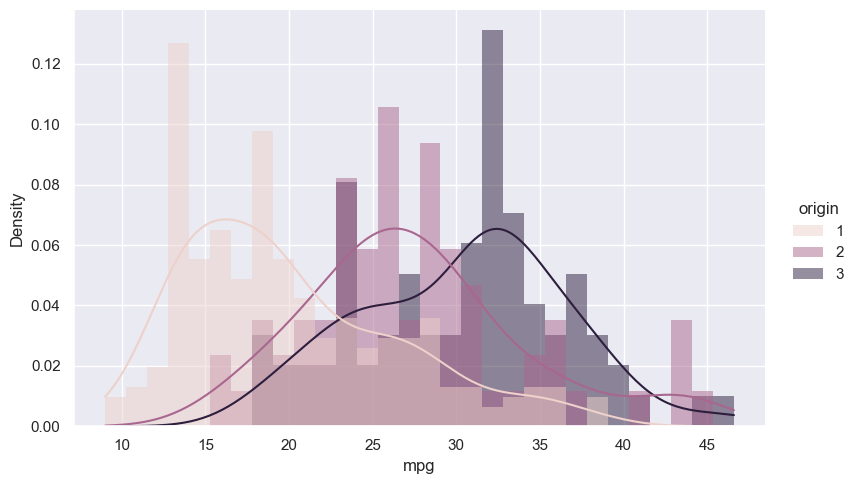

In [39]:
# Creates graph comparing normalized vehicle count to mpg, based on origin
sns.displot(df, x='mpg', hue='origin', bins=30, 
            linewidth=0, kde=True, stat='density',
            common_norm=False, height=5, aspect=1.6);

<b>Observation:</b> American vehicles are the least fuel efficient, on average, by a large margin, while Japanese vehicles are the most, considerably ahead European vehicles.

#### Visualizing model year correlation to mpg

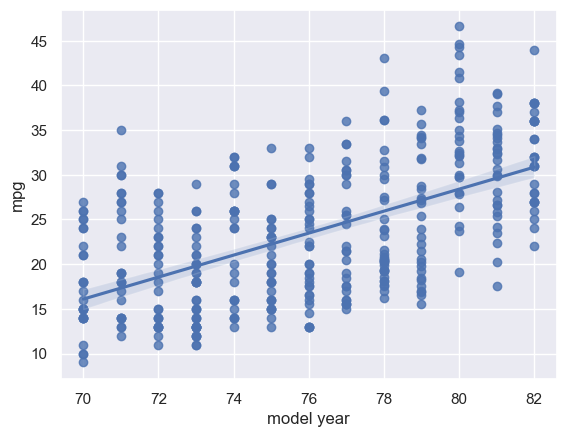

In [55]:
# Scatterplot, with regression line
sns.regplot(data=df, x='model year', y='mpg');

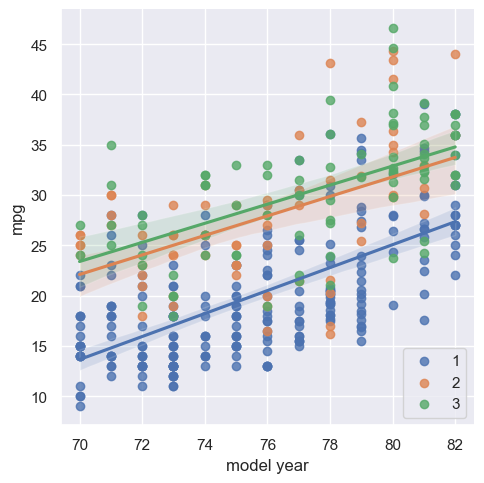

In [54]:
# Scatter plot grouping origin of each data point, with regression line
sns.lmplot(data=df, x='model year', y='mpg', hue='origin', legend=False);
plt.legend(loc='lower right');

<b>Observations:</b>
<ul>
    <li>There is a clear positive correlation between model year and mpg</li>
    <li>Factoring origin makes no difference in correlation between model year and mpg</li>
</ul>

#### Visualizing acceleration correlation to mpg

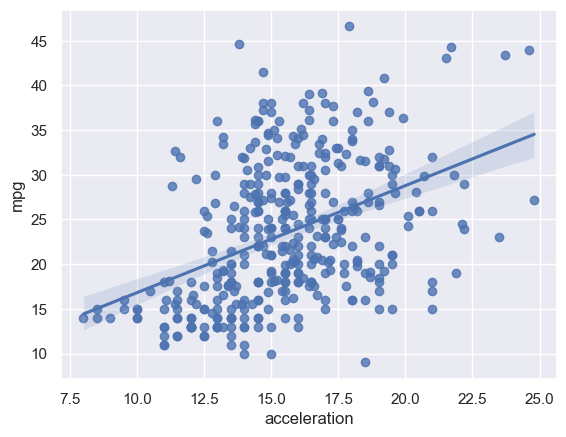

In [58]:
sns.regplot(data=df, x='acceleration', y='mpg');

<b>Observation:</b> there appears to be a slight correlation between acceleration and mpg, however, there is high variation after roughly 12.5s acceleration.